# 01 - LendingClub EDA

Goal: prepare the LendingClub sample for Phase 1 credit risk modeling.

This notebook intentionally focuses only on the risk-model dataset. It does not cover SHAP, document processing, fraud rules, reports, or Streamlit.

## 1. Setup

Use a bounded sample from the raw LendingClub CSV to stay friendly to an 8 GB RAM machine.

In [1]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 120)
pd.set_option("display.float_format", "{:.2f}".format)

sns.set_theme(style="whitegrid", palette="muted")

In [2]:
DATA_PATH = Path("../data/lendingclub/raw/accepted_2007_to_2018Q4.csv")
N_ROWS = 500_000
RANDOM_STATE = 42
PLOT_SAMPLE_SIZE = 50_000

DATA_PATH.exists(), DATA_PATH

(True, WindowsPath('../data/lendingclub/raw/accepted_2007_to_2018Q4.csv'))

## 2. Load Sample

The raw file is large, so this notebook reads the first 500,000 rows. After filtering to known final outcomes, this produces the current working dataset.

In [3]:
df = pd.read_csv(
    DATA_PATH,
    nrows=N_ROWS,
    low_memory=False,
)

df.shape

(500000, 151)

In [4]:
df.head()

,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,verification_status,issue_d,loan_status,pymnt_plan,url,desc,purpose,title,zip_code,addr_state,dti,delinq_2yrs,earliest_cr_line,fico_range_low,fico_range_high,inq_last_6mths,mths_since_last_delinq,mths_since_last_record,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,out_prncp,out_prncp_inv,total_pymnt,total_pymnt_inv,total_rec_prncp,total_rec_int,total_rec_late_fee,recoveries,collection_recovery_fee,last_pymnt_d,last_pymnt_amnt,next_pymnt_d,last_credit_pull_d,last_fico_range_high,last_fico_range_low,collections_12_mths_ex_med,mths_since_last_major_derog,policy_code,application_type,annual_inc_joint,dti_joint,verification_status_joint,...,mths_since_recent_inq,mths_since_recent_revol_delinq,num_accts_ever_120_pd,num_actv_bc_tl,num_actv_rev_tl,num_bc_sats,num_bc_tl,num_il_tl,num_op_rev_tl,num_rev_accts,num_rev_tl_bal_gt_0,num_sats,num_tl_120dpd_2m,num_tl_30dpd,num_tl_90g_dpd_24m,num_tl_op_past_12m,pct_tl_nvr_dlq,percent_bc_gt_75,pub_rec_bankruptcies,tax_liens,tot_hi_cred_lim,total_bal_ex_mort,total_bc_limit,total_il_high_credit_limit,revol_bal_joint,sec_app_fico_range_low,sec_app_fico_range_high,sec_app_earliest_cr_line,sec_app_inq_last_6mths,sec_app_mort_acc,sec_app_open_acc,sec_app_revol_util,sec_app_open_act_il,sec_app_num_rev_accts,sec_app_chargeoff_within_12_mths,sec_app_collections_12_mths_ex_med,sec_app_mths_since_last_major_derog,hardship_flag,hardship_type,hardship_reason,hardship_status,deferral_term,hardship_amount,hardship_start_date,hardship_end_date,payment_plan_start_date,hardship_length,hardship_dpd,hardship_loan_status,orig_projected_additional_accrued_interest,hardship_payoff_balance_amount,hardship_last_payment_amount,disbursement_method,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term
0,68407277,NaN,3600.00,3600.00,3600.00,36 months,13.99,123.03,C,C4,leadman,10+ years,MORTGAGE,55000.00,Not Verified,Dec-2015,Fully Paid,n,https://lendingclub.com/browse/loanDetail.acti...,NaN,debt_consolidation,Debt consolidation,190xx,PA,5.91,0.00,Aug-2003,675.00,679.00,1.00,30.00,NaN,7.00,0.00,2765.00,29.70,13.00,w,0.00,0.00,4421.72,4421.72,3600.00,821.72,0.00,0.00,0.00,Jan-2019,122.67,NaN,Mar-2019,564.00,560.00,0.00,30.00,1.00,Individual,NaN,NaN,NaN,...,4.00,69.00,2.00,2.00,4.00,2.00,5.00,3.00,4.00,9.00,4.00,7.00,0.00,0.00,0.00,3.00,76.90,0.00,0.00,0.00,178050.00,7746.00,2400.00,13734.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
1,68355089,NaN,24700.00,24700.00,24700.00,36 months,11.99,820.28,C,C1,Engineer,10+ years,MORTGAGE,65000.00,Not Verified,Dec-2015,Fully Paid,n,https://lendingclub.com/browse/loanDetail.acti...,NaN,small_business,Business,577xx,SD,16.06,1.00,Dec-1999,715.00,719.00,4.00,6.00,NaN,22.00,0.00,21470.00,19.20,38.00,w,0.00,0.00,25679.66,25679.66,24700.00,979.66,0.00,0.00,0.00,Jun-2016,926.35,NaN,Mar-2019,699.00,695.00,0.00,NaN,1.00,Individual,NaN,NaN,NaN,...,0.00,6.00,0.00,5.00,5.00,13.00,17.00,6.00,20.00,27.00,5.00,22.00,0.00,0.00,0.00,2.00,97.40,7.70,0.00,0.00,314017.00,39475.00,79300.00,24667.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
2,68341763,NaN,20000.00,20000.00,20000.00,60 months,10.78,432.66,B,B4,truck driver,10+ years,MORTGAGE,63000.00,Not Verified,Dec-2015,Fully Paid,n,https://lendingclub.com/browse/loanDetail.acti...,NaN,home_improvement,NaN,605xx,IL,10.78,0.00,Aug-2000,695.00,699.00,0.00,NaN,NaN,6.00,0.00,7869.00,56.20,18.00,w,0.00,0.00,22705.92,22705.92,20000.00,2705.92,0.00,0.00,0.00,Jun-2017,15813.30,NaN,Mar-2019,704.00,700.00,0.00,NaN,1.00,Joint App,71000.00,13.85,Not Verified,...,10.00,NaN,0.00,2.00,3.00,2.00,4.00,6.00,4.00,7.00,3.00,6.00,0.00,0.00,0.

In [5]:
memory_mb = df.memory_usage(deep=True).sum() / 1024**2
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]:,}")
print(f"Memory usage: {memory_mb:.2f} MB")

Rows: 500,000
Columns: 151
Memory usage: 687.39 MB


## 3. Target Definition

For supervised credit risk modeling, keep only loans with known final outcomes:

- `Fully Paid` -> non-default class `0`
- `Charged Off` -> default / loss class `1`

Other statuses are excluded because they are unresolved, transitional, or too rare for this first modeling phase.

In [6]:
loan_status_counts = df["loan_status"].value_counts(dropna=False)
loan_status_counts

loan_status
Fully Paid            312340
Current               104240
Charged Off            78824
Late (31-120 days)      2977
In Grace Period         1046
Late (16-30 days)        567
Default                    4
NaN                        2
Name: count, dtype: int64

In [7]:
final_statuses = ["Fully Paid", "Charged Off"]

status_keep_summary = (
    df["loan_status"]
    .isin(final_statuses)
    .value_counts()
    .rename(index={True: "keep_final_outcome", False: "exclude_non_final"})
)

status_keep_summary

loan_status
keep_final_outcome    391164
exclude_non_final     108836
Name: count, dtype: int64

In [8]:
df_clean = df[df["loan_status"].isin(final_statuses)].copy()

df_clean["target"] = df_clean["loan_status"].map({
    "Fully Paid": 0,
    "Charged Off": 1,
}).astype("int8")

df_clean.shape

(391164, 152)

In [9]:
target_distribution = pd.concat(
    [
        df_clean["loan_status"].value_counts().rename("count"),
        (df_clean["loan_status"].value_counts(normalize=True) * 100).rename("percentage"),
    ],
    axis=1,
)

target_distribution

,count,percentage
loan_status,,
Fully Paid,312340,79.85
Charged Off,78824,20.15


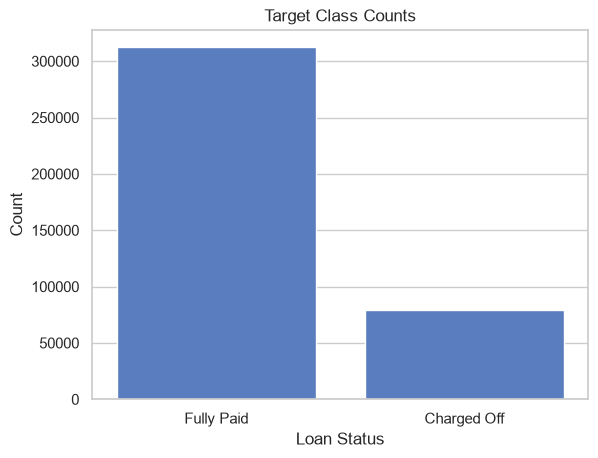

In [10]:
ax = sns.countplot(data=df_clean, x="loan_status", order=final_statuses)
ax.set_title("Target Class Counts")
ax.set_xlabel("Loan Status")
ax.set_ylabel("Count")
plt.show()

## 4. Missing Value Analysis

Columns with extremely high missingness are usually poor baseline candidates and can waste memory. This step identifies sparse fields before feature engineering.

In [15]:
missing_summary = (
    df_clean
    .isnull()
    .mean()
    .mul(100)
    .sort_values(ascending=False)
    .reset_index()
)

missing_summary.columns = ["column", "missing_percentage"]
missing_summary.head(50)

,column,missing_percentage
0,member_id,100.00
1,next_pymnt_d,100.00
2,desc,99.99
3,sec_app_mths_since_last_major_derog,99.80
4,orig_projected_additional_accrued_interest,99.64
5,hardship_length,99.52
6,hardship_status,99.52
7,deferral_term,99.52
8,hardship_end_date,99.52
9,hardship_reason,99.52


In [16]:
missing_buckets = pd.cut(
    missing_summary["missing_percentage"],
    bins=[-0.1, 0, 25, 50, 75, 100],
    labels=["0%", "0-25%", "25-50%", "50-75%", "75-100%"],
)

missing_bucket_summary = missing_buckets.value_counts().sort_index().rename("column_count")
missing_bucket_summary

missing_percentage
0%         78
0-25%      16
25-50%      1
50-75%      3
75-100%    54
Name: column_count, dtype: int64

In [17]:
high_missing_cols = missing_summary.loc[
    missing_summary["missing_percentage"] >= 50,
    "column",
].tolist()

print(f"Columns with >=50% missing values: {len(high_missing_cols)}")
high_missing_cols[:50]

Columns with >=50% missing values: 57


['member_id',
 'next_pymnt_d',
 'desc',
 'sec_app_mths_since_last_major_derog',
 'orig_projected_additional_accrued_interest',
 'hardship_length',
 'hardship_status',
 'deferral_term',
 'hardship_end_date',
 'hardship_reason',
 'hardship_start_date',
 'hardship_type',
 'hardship_loan_status',
 'hardship_payoff_balance_amount',
 'hardship_dpd',
 'payment_plan_start_date',
 'hardship_last_payment_amount',
 'hardship_amount',
 'sec_app_revol_util',
 'sec_app_collections_12_mths_ex_med',
 'sec_app_fico_range_low',
 'sec_app_open_acc',
 'sec_app_num_rev_accts',
 'revol_bal_joint',
 'sec_app_open_act_il',
 'sec_app_fico_range_high',
 'sec_app_earliest_cr_line',
 'sec_app_inq_last_6mths',
 'sec_app_chargeoff_within_12_mths',
 'sec_app_mort_acc',
 'verification_status_joint',
 'dti_joint',
 'annual_inc_joint',
 'settlement_status',
 'settlement_percentage',
 'debt_settlement_flag_date',
 'settlement_amount',
 'settlement_term',
 'settlement_date',
 'il_util',
 'mths_since_rcnt_il',
 'all_util'

## 5. Data Types and Cardinality

Separate numeric, categorical, and date-like fields so the next notebook can engineer features cleanly.

In [18]:
dtype_summary = (
    df_clean
    .dtypes
    .astype(str)
    .value_counts()
    .rename_axis("dtype")
    .reset_index(name="column_count")
)

dtype_summary

,dtype,column_count
0,float64,113
1,str,38
2,int8,1


In [19]:
numeric_cols = df_clean.select_dtypes(include="number").columns.tolist()
object_cols = df_clean.select_dtypes(include="object").columns.tolist()

print(f"Numeric columns: {len(numeric_cols)}")
print(f"Object columns: {len(object_cols)}")

Numeric columns: 114
Object columns: 38


In [20]:
cardinality_summary = (
    df_clean[object_cols]
    .nunique(dropna=True)
    .sort_values(ascending=False)
    .reset_index()
)

cardinality_summary.columns = ["column", "unique_values"]
cardinality_summary.head(30)

,column,unique_values
0,id,391164
1,url,391164
2,emp_title,113033
3,zip_code,910
4,earliest_cr_line,693
5,sec_app_earliest_cr_line,409
6,last_credit_pull_d,52
7,last_pymnt_d,51
8,addr_state,50
9,settlement_date,47


In [21]:
for col in ["term", "grade", "sub_grade", "emp_length", "home_ownership", "verification_status", "purpose", "application_type"]:
    if col in df_clean.columns:
        display(
            df_clean[col]
            .value_counts(dropna=False)
            .head(20)
            .rename_axis(col)
            .reset_index(name="count")
        )

,term,count
0,36 months,294375
1,60 months,96789


,grade,count
0,B,111201
1,C,108792
2,A,75359
3,D,56162
4,E,29331
5,F,8394
6,G,1925


,sub_grade,count
0,C1,24283
1,C2,23371
2,B4,23204
3,B3,22814
4,B5,22709
5,A5,22583
6,C3,22192
7,C4,21685
8,B2,21398
9,B1,21076


,emp_length,count
0,10+ years,129108
1,2 years,35225
2,< 1 year,32104
3,3 years,31265
4,1 year,25953
5,NaN,23471
6,5 years,23323
7,4 years,23030
8,8 years,19745
9,7 years,17012


,home_ownership,count
0,MORTGAGE,189879
1,RENT,158126
2,OWN,43156
3,ANY,3


,verification_status,count
0,Source Verified,169735
1,Verified,114185
2,Not Verified,107244


,purpose,count
0,debt_consolidation,230090
1,credit_card,93081
2,home_improvement,23964
3,other,19538
4,major_purchase,7248
5,medical,3976
6,car,3413
7,small_business,3266
8,moving,2437
9,vacation,2320


,application_type,count
0,Individual,388582
1,Joint App,2582


## 6. Leakage and Post-Origination Fields

The model should predict risk at application/origination time. Columns that reveal future repayment behavior must not be used for training.

In [22]:
leakage_keywords = [
    "out_prncp", "total_pymnt", "recover", "collection", "last_pymnt",
    "next_pymnt", "last_credit_pull", "settlement", "hardship", "debt_settlement", "total_rec",
]

leakage_candidates = sorted([
    col for col in df_clean.columns
    if any(keyword in col.lower() for keyword in leakage_keywords)
])

print(f"Potential leakage/post-origination columns: {len(leakage_candidates)}")
leakage_candidates

Potential leakage/post-origination columns: 31


['collection_recovery_fee',
 'collections_12_mths_ex_med',
 'debt_settlement_flag',
 'debt_settlement_flag_date',
 'hardship_amount',
 'hardship_dpd',
 'hardship_end_date',
 'hardship_flag',
 'hardship_last_payment_amount',
 'hardship_length',
 'hardship_loan_status',
 'hardship_payoff_balance_amount',
 'hardship_reason',
 'hardship_start_date',
 'hardship_status',
 'hardship_type',
 'last_credit_pull_d',
 'last_pymnt_amnt',
 'last_pymnt_d',
 'next_pymnt_d',
 'out_prncp',
 'out_prncp_inv',
 'recoveries',
 'sec_app_collections_12_mths_ex_med',
 'settlement_amount',
 'settlement_date',
 'settlement_percentage',
 'settlement_status',
 'settlement_term',
 'total_pymnt',
 'total_pymnt_inv']

In [23]:
id_or_text_cols = [
    "id", "member_id", "url", "desc", "title", "emp_title", "zip_code",
]

id_or_text_cols = [col for col in id_or_text_cols if col in df_clean.columns]
id_or_text_cols

['id', 'member_id', 'url', 'desc', 'title', 'emp_title', 'zip_code']

## 7. Numeric Feature Overview

Review numeric feature distributions and class-level differences. This is not final feature selection; it is an EDA screen for obvious issues.

In [24]:
base_exclude_cols = set([
    "target", "loan_status",
    *leakage_candidates,
    *id_or_text_cols,
])

candidate_numeric_cols = [
    col for col in numeric_cols
    if col not in base_exclude_cols
]

print(f"Candidate numeric columns before missingness filtering: {len(candidate_numeric_cols)}")
candidate_numeric_cols[:60]

Candidate numeric columns before missingness filtering: 95


['loan_amnt',
 'funded_amnt',
 'funded_amnt_inv',
 'int_rate',
 'installment',
 'annual_inc',
 'dti',
 'delinq_2yrs',
 'fico_range_low',
 'fico_range_high',
 'inq_last_6mths',
 'mths_since_last_delinq',
 'mths_since_last_record',
 'open_acc',
 'pub_rec',
 'revol_bal',
 'revol_util',
 'total_acc',
 'total_rec_prncp',
 'total_rec_int',
 'total_rec_late_fee',
 'last_fico_range_high',
 'last_fico_range_low',
 'mths_since_last_major_derog',
 'policy_code',
 'annual_inc_joint',
 'dti_joint',
 'acc_now_delinq',
 'tot_coll_amt',
 'tot_cur_bal',
 'open_acc_6m',
 'open_act_il',
 'open_il_12m',
 'open_il_24m',
 'mths_since_rcnt_il',
 'total_bal_il',
 'il_util',
 'open_rv_12m',
 'open_rv_24m',
 'max_bal_bc',
 'all_util',
 'total_rev_hi_lim',
 'inq_fi',
 'total_cu_tl',
 'inq_last_12m',
 'acc_open_past_24mths',
 'avg_cur_bal',
 'bc_open_to_buy',
 'bc_util',
 'chargeoff_within_12_mths',
 'delinq_amnt',
 'mo_sin_old_il_acct',
 'mo_sin_old_rev_tl_op',
 'mo_sin_rcnt_rev_tl_op',
 'mo_sin_rcnt_tl',
 'mort

In [25]:
numeric_profile = df_clean[candidate_numeric_cols].describe().T
numeric_profile["missing_percentage"] = df_clean[candidate_numeric_cols].isna().mean() * 100
numeric_profile.sort_values("missing_percentage", ascending=False).head(40)

,count,mean,std,min,25%,50%,75%,max,missing_percentage
sec_app_mths_since_last_major_derog,779.00,35.48,24.31,0.00,13.00,33.00,56.00,98.00,99.80
orig_projected_additional_accrued_interest,1422.00,295.97,273.91,1.92,97.08,192.99,430.61,1914.39,99.64
deferral_term,1876.00,3.00,0.00,3.00,3.00,3.00,3.00,3.00,99.52
sec_app_revol_util,2135.00,56.29,27.13,0.00,35.30,59.30,78.30,163.90,99.45
sec_app_fico_range_high,2181.00,668.64,49.17,544.00,639.00,669.00,694.00,834.00,99.44
sec_app_inq_last_6mths,2181.00,0.78,1.14,0.00,0.00,0.00,1.00,6.00,99.44
sec_app_mort_acc,2181.00,1.70,1.87,0.00,0.00,1.00,3.00,14.00,99.44
sec_app_num_rev_accts,2181.00,12.75,8.25,0.00,7.00,11.00,17.00,54.00,99.44
sec_app_open_acc,2181.00,11.23,6.38,0.00,7.00,10.00,15.00,48.00,99.44
sec_app_open_act_il,2181.00,2.77,2.99,0.00,1.00,2.00,4.00,26.00,99.44


In [26]:
important_numeric_cols = [
    "loan_amnt", "funded_amnt", "int_rate", "installment", "annual_inc", "dti",
    "fico_range_low", "fico_range_high", "open_acc", "pub_rec", "revol_bal",
    "revol_util", "total_acc", "mort_acc", "pub_rec_bankruptcies",
]

important_numeric_cols = [col for col in important_numeric_cols if col in df_clean.columns]

class_numeric_summary = (
    df_clean
    .groupby("target")[important_numeric_cols]
    .median()
    .T
    .rename(columns={0: "median_fully_paid", 1: "median_charged_off"})
)

class_numeric_summary["absolute_difference"] = (
    class_numeric_summary["median_charged_off"] - class_numeric_summary["median_fully_paid"]
)

class_numeric_summary.sort_values("absolute_difference", key=lambda s: s.abs(), ascending=False)

target,median_fully_paid,median_charged_off,absolute_difference
annual_inc,65000.00,60000.00,-5000.00
funded_amnt,12000.00,15000.00,3000.00
loan_amnt,12000.00,15000.00,3000.00
revol_bal,11465.00,11198.50,-266.50
installment,372.01,400.86,28.85
fico_range_high,694.00,684.00,-10.00
fico_range_low,690.00,680.00,-10.00
revol_util,52.00,55.90,3.90
int_rate,11.53,14.65,3.12
dti,17.76,20.68,2.92


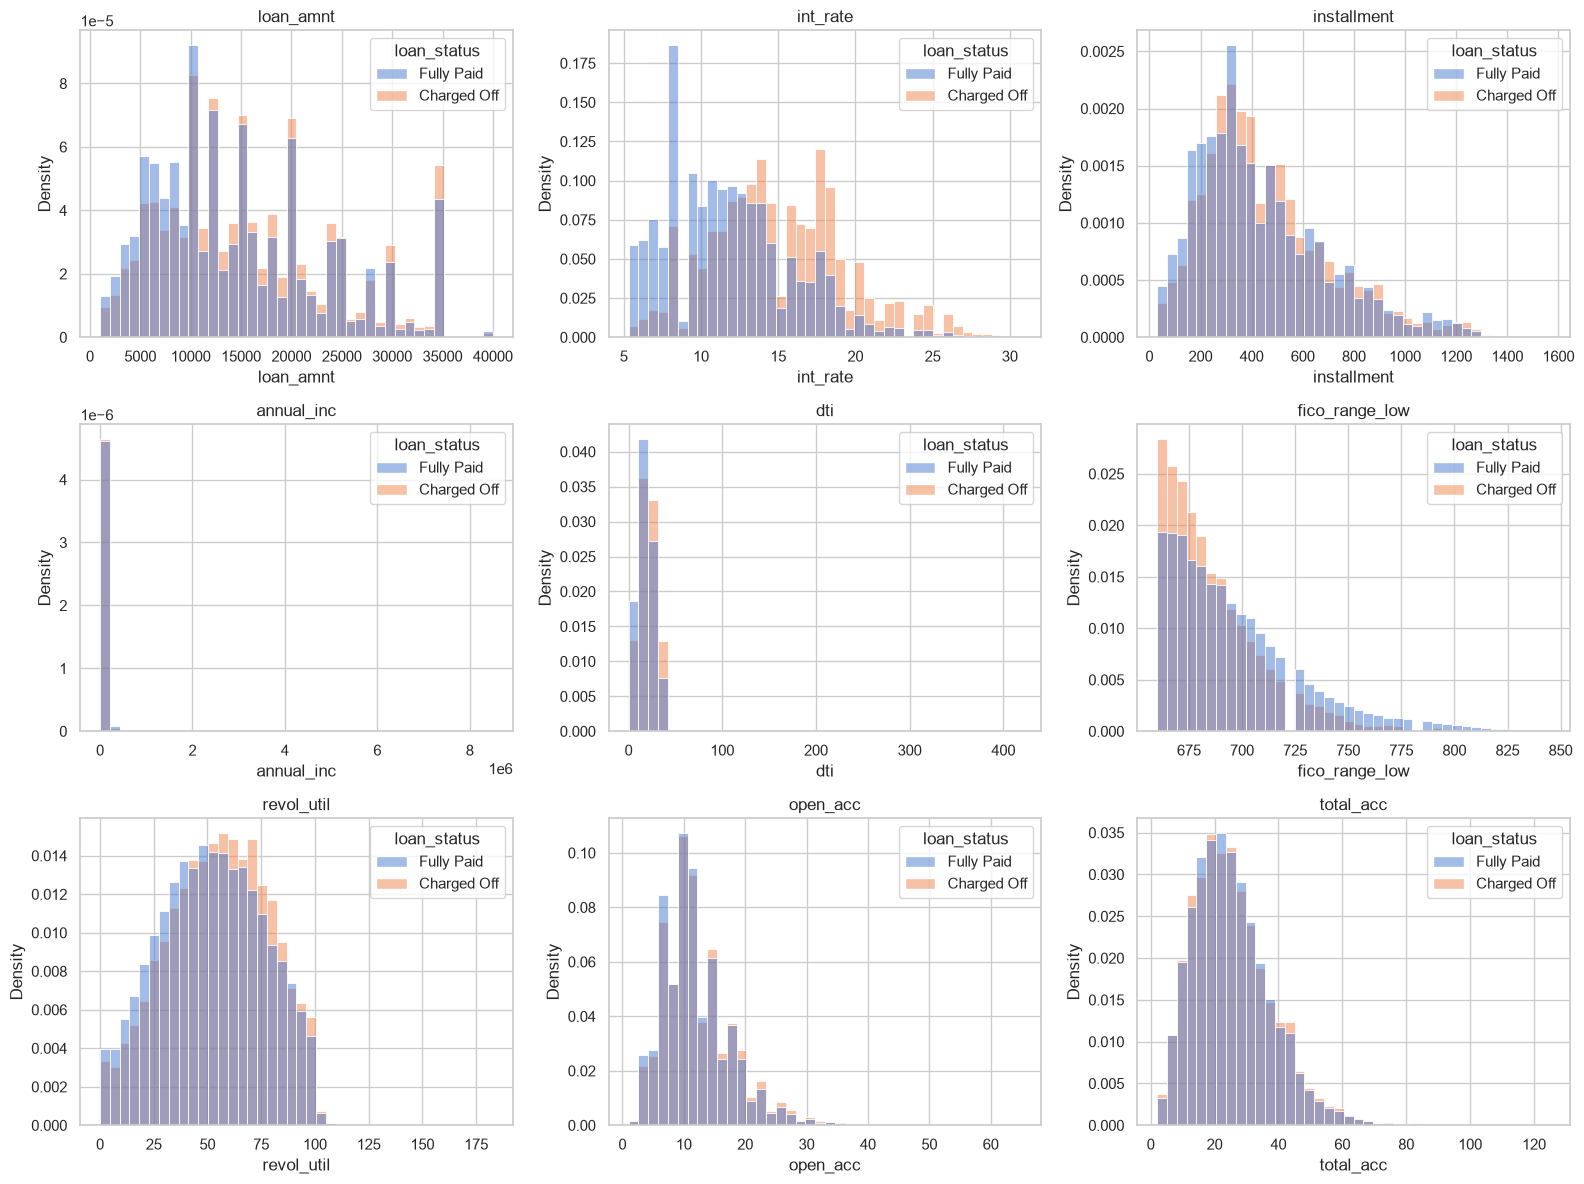

In [27]:
plot_df = df_clean.sample(
    n=min(PLOT_SAMPLE_SIZE, len(df_clean)),
    random_state=RANDOM_STATE,
)

plot_cols = [
    "loan_amnt", "int_rate", "installment", "annual_inc", "dti",
    "fico_range_low", "revol_util", "open_acc", "total_acc",
]
plot_cols = [col for col in plot_cols if col in plot_df.columns]

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()

for ax, col in zip(axes, plot_cols):
    sns.histplot(data=plot_df, x=col, hue="loan_status", bins=40, stat="density", common_norm=False, ax=ax)
    ax.set_title(col)

for ax in axes[len(plot_cols):]:
    ax.axis("off")

plt.tight_layout()
plt.show()

## 8. Categorical Feature Overview

Check major categorical fields against the target. These are likely useful after encoding in the feature engineering notebook.

In [28]:
def default_rate_by_category(data, column, min_count=500):
    summary = (
        data
        .groupby(column, dropna=False)
        .agg(
            row_count=("target", "size"),
            default_rate=("target", "mean"),
        )
        .reset_index()
    )
    summary["default_rate"] = summary["default_rate"] * 100
    return summary[summary["row_count"] >= min_count].sort_values("default_rate", ascending=False)

In [30]:
for col in ["grade", "sub_grade", "term", "home_ownership", "verification_status", "purpose"]:
    if col in df_clean.columns:
        print(f"\nDefault rate by {col}")
        display(default_rate_by_category(df_clean, col).head(20))


Default rate by grade


,grade,row_count,default_rate
6,G,1925,54.08
5,F,8394,50.92
4,E,29331,41.80
3,D,56162,32.25
2,C,108792,22.43
1,B,111201,13.06
0,A,75359,5.59



Default rate by sub_grade


,sub_grade,row_count,default_rate
29,F5,936,56.94
28,F4,1156,56.40
31,G2,508,52.56
27,F3,1463,51.74
30,G1,689,50.94
26,F2,2014,50.00
25,F1,2825,46.90
24,E5,3866,46.09
23,E4,4819,44.76
22,E3,6001,42.61



Default rate by term


...

,home_ownership,row_count,default_rate
3,RENT,158126,23.30
2,OWN,43156,20.53
1,MORTGAGE,189879,17.44



Default rate by verification_status


,verification_status,row_count,default_rate
2,Verified,114185,24.80
1,Source Verified,169735,20.64
0,Not Verified,107244,14.43



Default rate by purpose


,purpose,row_count,default_rate
11,small_business,3266,28.60
5,house,1601,23.86
8,moving,2437,23.14
2,debt_consolidation,230090,21.60
7,medical,3976,21.05
9,other,19538,20.70
6,major_purchase,7248,19.56
12,vacation,2320,18.36
4,home_improvement,23964,17.98
1,credit_card,93081,16.76


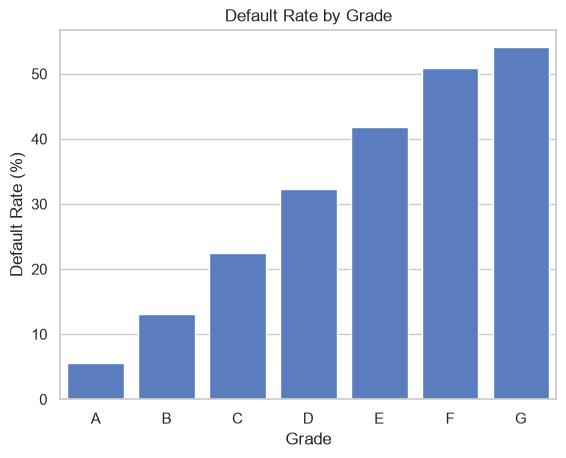

In [31]:
if "grade" in df_clean.columns:
    grade_summary = default_rate_by_category(df_clean, "grade", min_count=100)

    ax = sns.barplot(data=grade_summary, x="grade", y="default_rate", order=sorted(grade_summary["grade"].dropna()))
    ax.set_title("Default Rate by Grade")
    ax.set_xlabel("Grade")
    ax.set_ylabel("Default Rate (%)")
    plt.show()

## 9. Date and Vintage Checks

Loan issue dates can shift class distribution over time. This helps decide whether to use time-aware validation later.

In [32]:
if "issue_d" in df_clean.columns:
    df_clean["issue_date"] = pd.to_datetime(df_clean["issue_d"], format="%b-%Y", errors="coerce")
    df_clean["issue_year"] = df_clean["issue_date"].dt.year

    issue_summary = (
        df_clean
        .groupby("issue_year")
        .agg(
            row_count=("target", "size"),
            default_rate=("target", "mean"),
        )
        .reset_index()
    )
    issue_summary["default_rate"] = issue_summary["default_rate"] * 100
    display(issue_summary)

,issue_year,row_count,default_rate
0,2015,375545,20.18
1,2018,15619,19.34


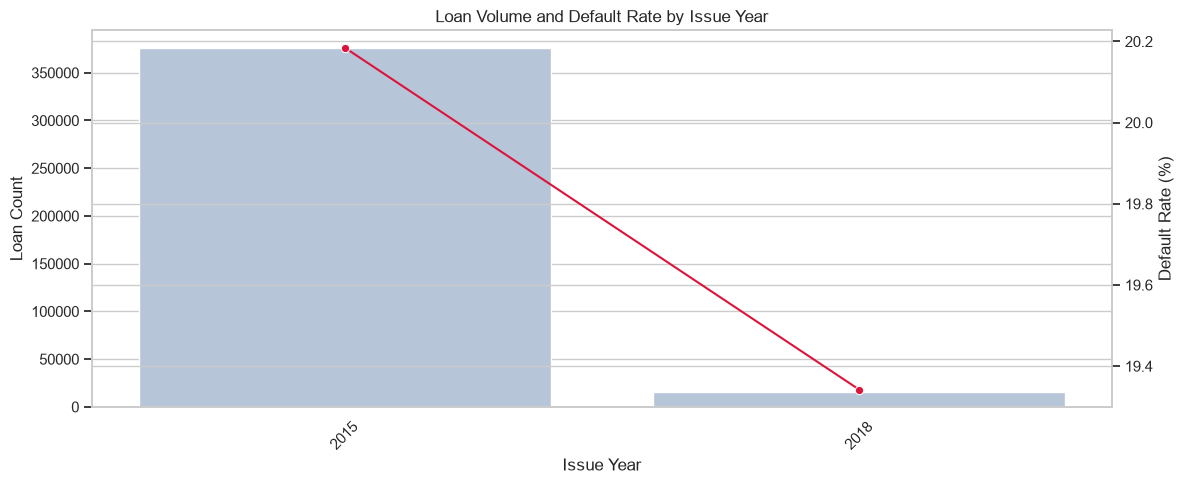

In [33]:
if "issue_year" in df_clean.columns:
    fig, ax1 = plt.subplots(figsize=(12, 5))

    sns.barplot(data=issue_summary, x="issue_year", y="row_count", color="lightsteelblue", ax=ax1)
    ax1.set_ylabel("Loan Count")
    ax1.set_xlabel("Issue Year")
    ax1.tick_params(axis="x", rotation=45)

    ax2 = ax1.twinx()
    sns.lineplot(data=issue_summary, x=range(len(issue_summary)), y="default_rate", marker="o", color="crimson", ax=ax2)
    ax2.set_ylabel("Default Rate (%)")

    plt.title("Loan Volume and Default Rate by Issue Year")
    plt.tight_layout()
    plt.show()

## 10. Correlation Screen

Use this only as a quick signal for duplicate or highly related numeric features. Tree models can handle correlation, but redundant fields can still add noise.

In [34]:
low_missing_numeric_cols = [
    col for col in candidate_numeric_cols
    if df_clean[col].isna().mean() <= 0.30
]

corr_with_target = (
    df_clean[low_missing_numeric_cols + ["target"]]
    .corr(numeric_only=True)["target"]
    .drop("target")
    .sort_values(key=lambda s: s.abs(), ascending=False)
)

corr_with_target.head(30)

last_fico_range_high    -0.67
last_fico_range_low     -0.58
total_rec_prncp         -0.44
int_rate                 0.30
fico_range_low          -0.13
fico_range_high         -0.13
total_rec_late_fee       0.13
acc_open_past_24mths     0.12
dti                      0.10
num_tl_op_past_12m       0.10
inq_last_6mths           0.09
total_rec_int            0.09
bc_open_to_buy          -0.09
avg_cur_bal             -0.08
total_bc_limit          -0.08
tot_hi_cred_lim         -0.08
num_rev_tl_bal_gt_0      0.07
num_actv_rev_tl          0.07
percent_bc_gt_75         0.07
tot_cur_bal             -0.07
mort_acc                -0.07
mo_sin_rcnt_tl          -0.07
loan_amnt                0.07
funded_amnt              0.07
funded_amnt_inv          0.07
bc_util                  0.07
mths_since_recent_inq   -0.06
mo_sin_rcnt_rev_tl_op   -0.06
mths_since_recent_bc    -0.06
mo_sin_old_rev_tl_op    -0.06
Name: target, dtype: float64

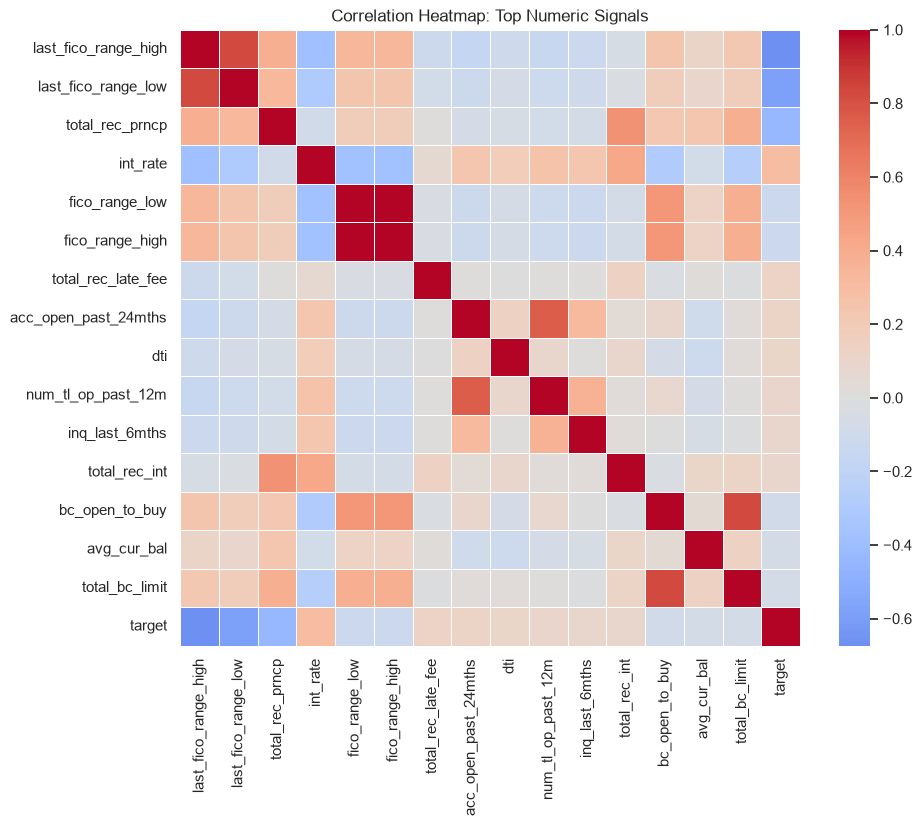

In [35]:
top_corr_cols = corr_with_target.head(15).index.tolist()

plt.figure(figsize=(10, 8))
sns.heatmap(
    df_clean[top_corr_cols + ["target"]].corr(numeric_only=True),
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
)
plt.title("Correlation Heatmap: Top Numeric Signals")
plt.show()

## 11. Baseline Feature Candidate List

This list is a practical handoff into `02_feature_engineering.ipynb`. It excludes obvious leakage, ID/text-heavy fields, and columns with more than 50% missing values.

In [36]:
cols_missing_under_50 = set(
    missing_summary.loc[missing_summary["missing_percentage"] < 50, "column"]
)

excluded_for_baseline = set([
    "loan_status", "target", "issue_date", "issue_year",
    *leakage_candidates,
    *id_or_text_cols,
])

baseline_feature_candidates = [
    col for col in df_clean.columns
    if col in cols_missing_under_50 and col not in excluded_for_baseline
]

print(f"Baseline feature candidates: {len(baseline_feature_candidates)}")
baseline_feature_candidates

Baseline feature candidates: 76


['loan_amnt',
 'funded_amnt',
 'funded_amnt_inv',
 'term',
 'int_rate',
 'installment',
 'grade',
 'sub_grade',
 'emp_length',
 'home_ownership',
 'annual_inc',
 'verification_status',
 'issue_d',
 'pymnt_plan',
 'purpose',
 'addr_state',
 'dti',
 'delinq_2yrs',
 'earliest_cr_line',
 'fico_range_low',
 'fico_range_high',
 'inq_last_6mths',
 'mths_since_last_delinq',
 'open_acc',
 'pub_rec',
 'revol_bal',
 'revol_util',
 'total_acc',
 'initial_list_status',
 'total_rec_prncp',
 'total_rec_int',
 'total_rec_late_fee',
 'last_fico_range_high',
 'last_fico_range_low',
 'policy_code',
 'application_type',
 'acc_now_delinq',
 'tot_coll_amt',
 'tot_cur_bal',
 'total_rev_hi_lim',
 'acc_open_past_24mths',
 'avg_cur_bal',
 'bc_open_to_buy',
 'bc_util',
 'chargeoff_within_12_mths',
 'delinq_amnt',
 'mo_sin_old_il_acct',
 'mo_sin_old_rev_tl_op',
 'mo_sin_rcnt_rev_tl_op',
 'mo_sin_rcnt_tl',
 'mort_acc',
 'mths_since_recent_bc',
 'mths_since_recent_inq',
 'num_accts_ever_120_pd',
 'num_actv_bc_tl',


In [37]:
baseline_feature_summary = pd.DataFrame({
    "column": baseline_feature_candidates,
    "dtype": [str(df_clean[col].dtype) for col in baseline_feature_candidates],
    "missing_percentage": [df_clean[col].isna().mean() * 100 for col in baseline_feature_candidates],
    "unique_values": [df_clean[col].nunique(dropna=True) for col in baseline_feature_candidates],
}).sort_values(["dtype", "missing_percentage", "unique_values"])

baseline_feature_summary

,column,dtype,missing_percentage,unique_values
34,policy_code,float64,0.00,1
64,num_tl_30dpd,float64,0.00,5
21,inq_last_6mths,float64,0.00,7
36,acc_now_delinq,float64,0.00,8
44,chargeoff_within_12_mths,float64,0.00,10
69,pub_rec_bankruptcies,float64,0.00,11
65,num_tl_90g_dpd_24m,float64,0.00,24
70,tax_liens,float64,0.00,24
17,delinq_2yrs,float64,0.00,26
24,pub_rec,float64,0.00,27


## 12. EDA Conclusions

Current Phase 1 findings:

- The working sample uses known final outcomes only: `Fully Paid` and `Charged Off`.
- The target is imbalanced but usable for a baseline model: roughly 80% non-default and 20% charged-off in the current sample.
- Many LendingClub columns are sparse; columns with at least 50% missingness should be excluded from the first baseline model.
- Repayment, recovery, hardship, settlement, and last-payment fields are potential leakage and should be excluded from model training.
- Strong baseline candidates include application/origination fields such as loan amount, term, interest rate, grade, income, DTI, FICO ranges, credit history counts, revolving utilization, purpose, and verification status.
- The next notebook should build a memory-efficient feature table from the `baseline_feature_candidates` list and train only after leakage controls are applied.